In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import natural_units as nu

output_tag = '20251029'
output_file = '../test/initial/' + output_tag + '/result-' + output_tag + '.txt'

rho_s     = 1.28e7 * nu.mSun / nu.kpc**3
r_s       = 6.5 * nu.kpc

sigma_fid = 1 / rho_s / r_s
v_fid     = np.sqrt(4 * np.pi * nu.G_Newton * rho_s) * r_s
lumi_fid  = np.power(4 * np.pi * rho_s * r_s**2, 5/2) * np.power(nu.G_Newton, 3/2)
t_fid     = 1 / np.sqrt(4 * np.pi * nu.G_Newton * rho_s)
C_fid     = np.power(4 * np.pi * nu.G_Newton, 3/2) * np.power(rho_s, 5/2) * r_s**2

In [124]:
def _decade_bounds(vmin, vmax):
    """给定正数范围，返回包含它们的整十次幂上下界 kmin, kmax（log10 空间的整数）"""
    if vmin <= 0 or vmax <= 0:
        raise ValueError("log 轴范围必须为正数")
    kmin = int(np.floor(np.log10(vmin)))
    kmax = int(np.ceil (np.log10(vmax)))
    if kmin == kmax:  # 避免退化：只有一个十倍数区间时扩一点
        kmin -= 1
        kmax += 1
    return kmin, kmax

def _make_log_ticks(vmin, vmax):
    """
    自动生成 log 轴的主/次刻度：
    - 主刻度：10^k
    - 次刻度：m*10^k, m=2..9
    返回：(positions_log10, labels_str, minor_positions_log10)
    """
    kmin, kmax = _decade_bounds(vmin, vmax)
    majors = []
    minors = []
    for k in range(kmin, kmax + 1):
        majors.append(10.0**k)
        for m in range(2, 10):  # 2..9
            minors.append(m * 10.0**k)
    # 仅保留在范围内的
    majors = [x for x in majors if vmin <= x <= vmax]
    minors = [x for x in minors if vmin <= x <= vmax]
    # 位置映射到 log10 空间
    major_pos = np.log10(majors) if majors else []
    minor_pos = np.log10(minors) if minors else []
    # 标签：主刻度显示 1e±k，次刻度不标（避免乱）
    major_lbl = [f"1e{int(np.log10(x))}" for x in majors]
    return major_pos, major_lbl, minor_pos


def read_output(filename):
    data_blocks = []
    core_density = np.array([])
    time_points = np.array([])
    core_velocity = np.array([])
    core_kn = np.array([])
    with open(filename, 'r') as f:
        lines = f.readlines()

    # 跳过开头的说明文字，找到 "time, step, ..." 之后
    start_idx = None
    for i, line in enumerate(lines):
        if "Cross section (sigma)" in line:
            sigma = float(line.split(":")[1])
        if line.strip().startswith("time, step"):
            start_idx = i + 1
            break
    if start_idx is None:
        raise ValueError("找不到数据开头标记")

    i = start_idx
    while i < len(lines):
        # 1. 时间和步数
        parts = lines[i].split()
        if len(parts) < 2:
            break
        time = float(parts[0])
        step = int(parts[1])
        i += 1

        # 2. 六个数组
        RList  = np.fromstring(lines[i], sep=' '); i += 1
        RhoList= np.fromstring(lines[i], sep=' '); i += 1
        MList  = np.fromstring(lines[i], sep=' '); i += 1
        uList  = np.fromstring(lines[i], sep=' '); i += 1
        LList  = np.fromstring(lines[i], sep=' '); i += 1
        CList  = np.fromstring(lines[i], sep=' '); i += 1

        block = {
            "time": time,
            "step": step,
            "R": RList,
            "rho": RhoList,
            "M": MList,
            "u": uList,
            "L": LList,
            "C": CList
        }
        data_blocks.append(block)
        core_density = np.append(core_density, RhoList[0])
        time_points  = np.append(time_points, time) 
        core_velocity = np.append(core_velocity, np.sqrt( 2 / 3 * uList[0]))
        core_kn = np.append(core_kn, 1 / RhoList[0] / sigma / np.sqrt( 2 / 3 * uList[0] / RhoList[0]) )
    return data_blocks, core_density, time_points, core_velocity, core_kn

blocks, core_density, time_points, core_velocity, core_kn = read_output(output_file)
print("读到 %d 个时间片" % len(blocks))

读到 16863 个时间片


In [ ]:
def plot_rho_vs_r_3d(time_to_plot):
    xmin, xmax = 3e-3, 3e1
    ymin, ymax = 1e-1, 1e2
    zmin, zmax = 1e5, 1e14
    xmaj, xlbl, xminr = _make_log_ticks(xmin, xmax)
    ymaj, ylbl, yminr = _make_log_ticks(ymin, ymax)
    zmaj, zlbl, zminr = _make_log_ticks(zmin, zmax)

    fig = plt.figure(figsize=(8, 6), dpi=180)
    ax = fig.add_subplot(projection="3d")

    ax.set_xlim(np.log10(xmin), np.log10(xmax))
    ax.set_ylim(np.log10(ymin), np.log10(ymax))
    ax.set_zlim(np.log10(zmin), np.log10(zmax))

    # 设置主刻度位置与标签（标签显示原始值）
    ax.set_xticks(xmaj); ax.set_xticklabels(xlbl)
    ax.set_yticks(ymaj); ax.set_yticklabels(ylbl)
    ax.set_zticks(zmaj); ax.set_zticklabels(zlbl)

    # 设置次刻度（不打标签）
    # 3DAxes 支持 minor ticks，但不会自动画，需要手动启用
    ax.set_xticks(xminr, minor=True)
    ax.set_yticks(yminr, minor=True)
    ax.set_zticks(zminr, minor=True)

    # 打开次刻度可见性（不同后端可能需要调整）
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_tick_params(which='minor', length=3)   # 次刻度短
        axis.set_tick_params(which='major', length=6)   # 主刻度长

    # 只显示 major 网格线
    ax.grid(True, which='major', linewidth=0.4, color='gray', linestyle='-')
    ax.grid(False, which='minor')   # 明确关闭 minor 网格

    ax.set_xlabel(r"$r$ [kpc]")     # 改成你的单位
    ax.set_ylabel(r"$t$ [Gyr]")
    ax.set_zlabel(r"$\rho$ [M$_\odot$ kpc$^{-3}$]")
    ax.set_title(r"$\rho(r)$ at multiple times (3D log axes)")
    # 设置观察角度
    ax.view_init(elev=20)

    for tp in time_to_plot:
        datapoint = blocks[tp]
        x = np.log10(datapoint["R"] * r_s / nu.kpc)
        y = np.log10(np.full_like(x, datapoint["time"] * t_fid / (1e9 * nu.year)))
        z = np.log10(datapoint["rho"] * rho_s / (nu.mSun / nu.kpc**3))
        ax.plot(x, y, z, label=f"t index = {tp}")

    y_rho_plot = time_points  * t_fid / (1e9 * nu.year)
    z_rho_plot = core_density * rho_s / (nu.mSun / nu.kpc**3)
    x_rho_plot = np.full_like(y_rho_plot , 1e2)
    ax.plot(x_rho_plot, y_rho_plot, z_rho_plot)

    #ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

/var/folders/9v/y06d7lqs27q0yn2p9g1ttwp80000gn/T/ipykernel_54892/839075352.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


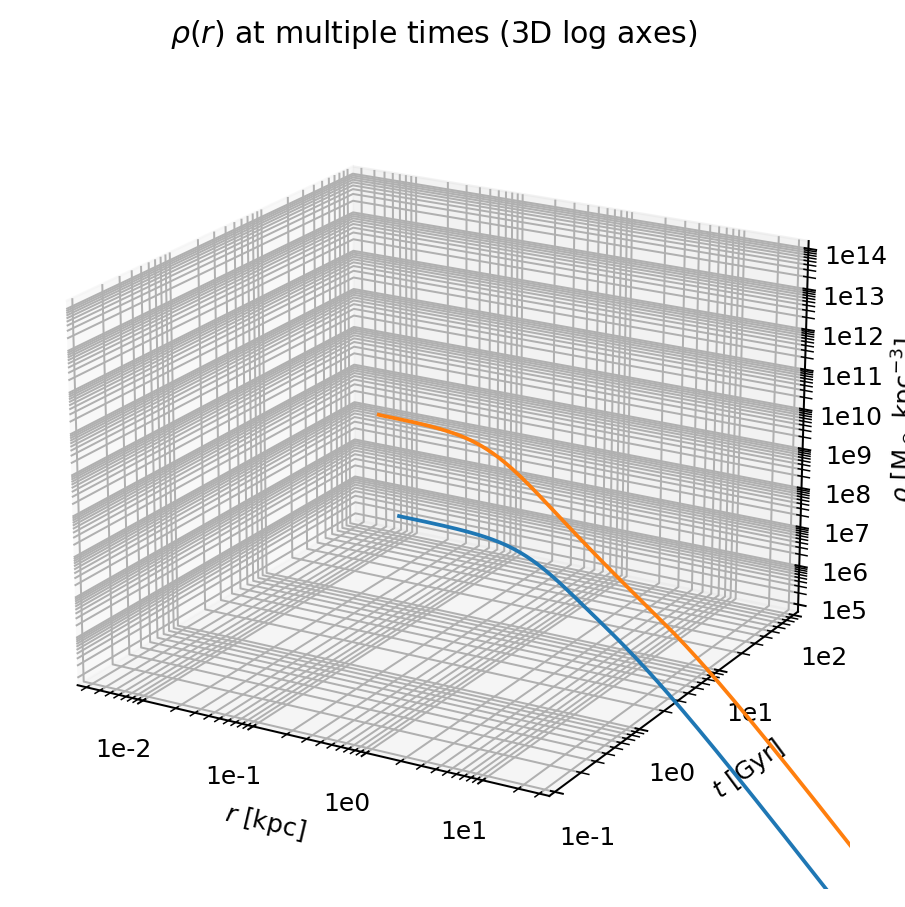

In [ ]:
plot_rho_vs_r_3d([1000,10000])

In [149]:
def nearest_indices(arr, vals):
    """在单调数组 arr 中，找到每个目标值 vals 最接近的下标"""
    arr = np.asarray(arr)
    vals = np.atleast_1d(vals)
    idx = np.array([np.abs(arr - v).argmin() for v in vals], dtype=int)
    return idx

def plot_rho_vs_r_2d(t_in_gyr, linewidth=2.0):
    """
    Plot ρ(r) at selected times in 2D log–log scale.
    Tick marks are on all four sides and point inward.
    """
    xmin, xmax = 1e-1, 2e1
    ymin, ymax = 1e6, 1e10

    fig, ax = plt.subplots(figsize=(6, 6), dpi=180)

    for tgyr in t_in_gyr:
        tp = nearest_indices(time_points, tgyr * 1e9 * nu.year / t_fid)[0]
        dp = blocks[tp]
        x = dp["R"] * r_s / nu.kpc
        y = dp["rho"] * rho_s / nu.mSun * nu.kpc**3
        ax.plot(x, y, lw=linewidth, label=fr"$t = {tgyr}\ \mathrm{{Gyr}}$")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(r"$r$ [kpc]")
    ax.set_ylabel(r"$\rho$ [M$_\odot$ kpc$^{-3}$]")
    ax.set_title(r"$\rho(r)$ at different times")

    # Tick marks on all sides, pointing inward
    ax.tick_params(axis='both', which='both',
                   direction='in',
                   top=True, right=True,
                   width=1.0)
    ax.tick_params(which='major', length=7, width=1.1)
    ax.tick_params(which='minor', length=4, width=0.8)

    # Major grid only
    ax.grid(True, which='major', linestyle=':', color='0.75', lw=0.6)
    ax.grid(False, which='minor')

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

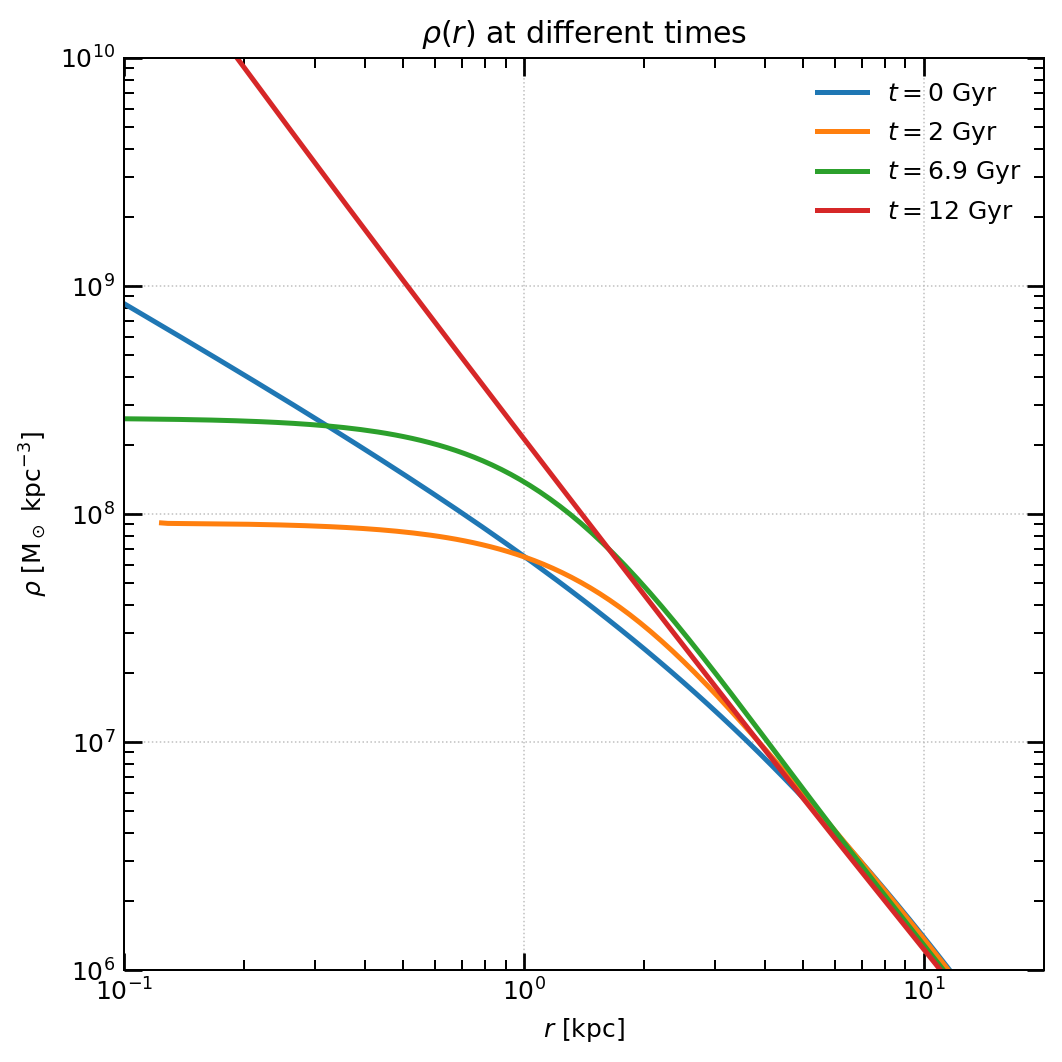

In [151]:
plot_rho_vs_r_2d([0, 2, 6.9, 12])

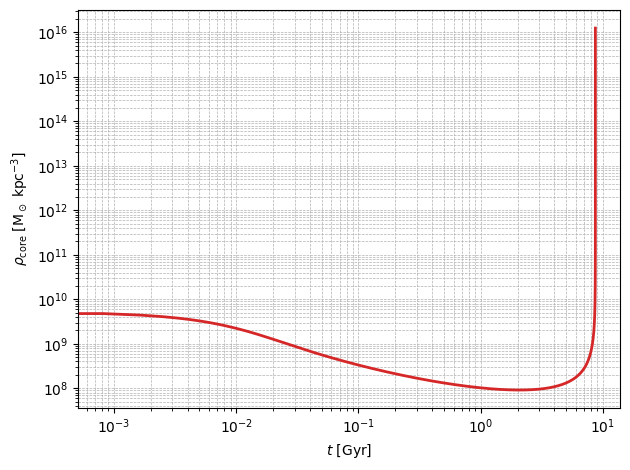

In [125]:
plt.loglog(time_points  * t_fid / (1e9 * nu.year), core_density * rho_s / (nu.mSun / nu.kpc**3), color='C3', lw=2)
plt.xlabel(r"$t$ [Gyr]")
plt.ylabel(r"$\rho_{\rm core}$ [M$_\odot$ kpc$^{-3}$]")
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

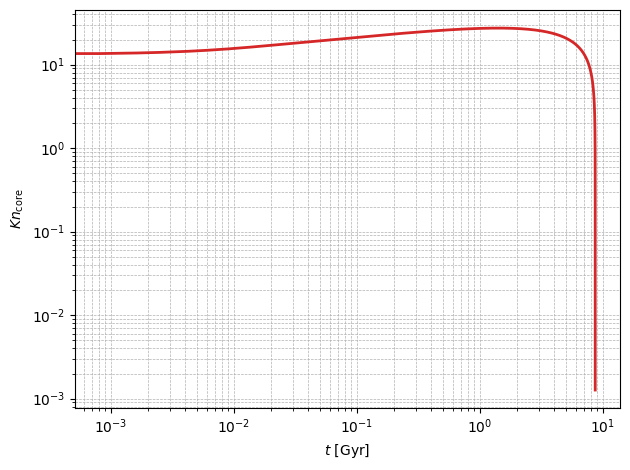

In [127]:
plt.loglog(time_points  * t_fid / (1e9 * nu.year), core_kn , color='C3', lw=2)
plt.xlabel(r"$t$ [Gyr]")
plt.ylabel(r"$Kn_{\rm core}$")
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

In [155]:
1e-22 / nu.MeV**2 / nu.cm**2

3.8937944929e-44